# 📧 Spam Email Detection Project

**Course / Institution:** INSA
**Task:** Build a machine learning pipeline that classifies SMS/email messages as **Spam** or **Ham** (legitimate).

This notebook follows the complete workflow required for the assignment:

> Dataset → Data Loading → EDA → Text Preprocessing → Feature Extraction (TF-IDF/BoW) → Train/Test Split → Model Training → Model Evaluation → Spam Prediction → Deployment

**Dataset used:** [SMS Spam Collection Dataset](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) — 5,572 labeled SMS messages (`ham` = legitimate, `spam` = unwanted/promotional).

---


## 📌 Step 1: Collect the Dataset

We use the **SMS Spam Collection Dataset**, a public dataset of 5,572 real SMS messages, each labeled as:

- **`ham`** → a legitimate, non-spam message
- **`spam`** → an unwanted or promotional message

The raw file is a CSV (`spam.csv`) with the text encoded in `latin-1`. It contains two useful columns (`v1` = label, `v2` = message text) plus three mostly-empty legacy columns that we will drop in the next step.


## 📌 Step 2: Load the Dataset

We load the CSV with **Pandas** and take a first look at its structure, shape, and columns.


In [1]:
import pandas as pd
import numpy as np

# Load the dataset (latin-1 encoding is required for this file)
df = pd.read_csv("../data/spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [2]:
print("Shape of the dataset:", df.shape)
df.info()

Shape of the dataset: (5572, 5)
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [3]:
# Keep only the two relevant columns and give them clear names
df = df[["v1", "v2"]]
df.rename(columns={"v1": "label", "v2": "message"}, inplace=True)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 📌 Step 3: Explore the Data (EDA)

Before modeling, we explore the dataset to understand:
- The balance between spam and ham messages (this dataset is **imbalanced**, which matters for model choice and evaluation metric).
- Whether there are missing values.
- Whether there are duplicate records (duplicates can leak information between train/test splits and inflate accuracy).
- How message length differs between spam and ham.


In [4]:
# Class distribution
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [5]:
df['label'].value_counts(normalize=True).mul(100).round(2)

label
ham     86.59
spam    13.41
Name: proportion, dtype: float64

In [6]:
# Missing values
df.isnull().sum()

label      0
message    0
dtype: int64

In [7]:
# Duplicate records
print("Duplicate rows before cleaning:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)

Duplicate rows before cleaning: 403
Duplicate rows after cleaning: 0
Shape after removing duplicates: (5169, 2)


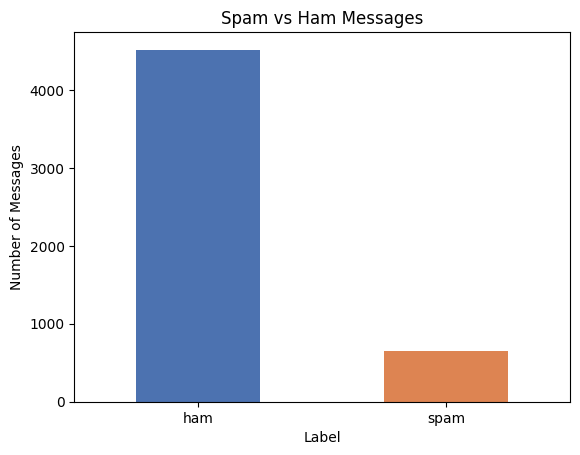

In [8]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title("Spam vs Ham Messages")
plt.xlabel("Label")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.show()

In [9]:
# Message length analysis - spam messages tend to be longer (promotional text)
df['length'] = df['message'].apply(len)
df['length'].describe()

count    5169.000000
mean       78.977945
std        58.236293
min         2.000000
25%        36.000000
50%        60.000000
75%       117.000000
max       910.000000
Name: length, dtype: float64

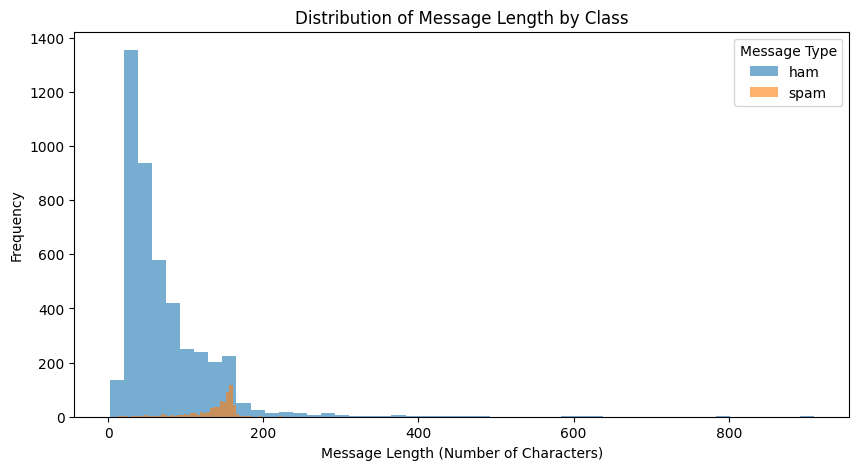

In [10]:
plt.figure(figsize=(10, 5))
for label in df['label'].unique():
    subset = df[df['label'] == label]
    plt.hist(subset['length'], bins=50, alpha=0.6, label=label)

plt.title("Distribution of Message Length by Class")
plt.xlabel("Message Length (Number of Characters)")
plt.ylabel("Frequency")
plt.legend(title="Message Type")
plt.show()

**EDA takeaways:**
- The dataset is **imbalanced** (~87% ham vs ~13% spam), so accuracy alone is not enough to judge a model — we also look at **precision, recall, and F1-score** for the spam class.
- There were no missing values, but there were duplicate rows, which we removed to avoid data leakage between the train and test sets.
- Spam messages are noticeably **longer on average** than ham messages, which is a useful (if implicit) signal for the model.


## 📌 Step 4: Preprocess the Text

Raw text is noisy. We clean it in these stages so the model can focus on meaningful words:

1. **Lowercase** — so `Free` and `free` are treated the same.
2. **Remove punctuation & special characters.**
3. **Remove numbers** — digits (phone numbers, prices) add noise for a bag-of-words model.
4. **Tokenize** — split the message into individual word tokens.
5. **Remove stop words** — common words (`the`, `is`, `and`...) that carry little meaning.
6. **Lemmatize** — reduce words to their base/dictionary form (e.g. `winning` → `win`).


In [11]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\isaak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\isaak\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\isaak\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\isaak\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\isaak\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [12]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. Tokenize into words
    tokens = word_tokenize(text)

    # 5. Remove stopwords (and any leftover non-alphabetic tokens)
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]

    # 6. Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

# Quick test of the cleaning function
clean_text("Congratulations!! You WON a FREE $1000 prize, call 08712345 NOW!!!")

'congratulation free prize call'

In [13]:
df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back id like fun...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile month u r entitled update latest colour...


## 📌 Step 5: Convert Text into Numerical Features

Machine learning models work with numbers, not raw text, so we need to vectorize the cleaned messages.

- **Bag of Words (BoW)** simply counts how many times each word appears in a message.
- **TF-IDF (Term Frequency–Inverse Document Frequency)** improves on BoW by down-weighting words that appear in *many* messages (like common filler words) and up-weighting words that are distinctive to a particular message. This generally works better for spam detection, so we use **TF-IDF** as our main feature representation.


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Bag of Words representation (for comparison / reference)
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(df['clean_message'])
print("Bag of Words matrix shape:", X_bow.shape)

# TF-IDF representation (used for modeling)
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['clean_message'])
print("TF-IDF matrix shape:", X.shape)

Bag of Words matrix shape: (5169, 7866)
TF-IDF matrix shape: (5169, 7866)


In [15]:
from sklearn.preprocessing import LabelEncoder

# Encode labels: ham -> 0, spam -> 1
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])

print("Classes:", list(encoder.classes_))
print(y[:10])

Classes: ['ham', 'spam']
[0 0 1 0 0 1 0 0 1 1]


## 📌 Step 6: Split the Dataset

We split the data into a **training set (80%)** and a **testing set (20%)**. We use `stratify=y` so that both sets keep the same spam/ham ratio as the full dataset — important since the classes are imbalanced.


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set: ", X_test.shape, y_test.shape)

Training set: (4135, 7866) (4135,)
Testing set:  (1034, 7866) (1034,)


## 📌 Step 7: Train the Machine Learning Model

Rather than committing to a single algorithm blindly, we train and compare **three** classic text-classification models:

1. **Multinomial Naive Bayes** — the classic baseline for text classification, fast and works well with TF-IDF/BoW counts.
2. **Logistic Regression** — a strong, interpretable linear baseline.
3. **Linear Support Vector Machine (LinearSVC)** — often the strongest linear model for high-dimensional sparse text data such as TF-IDF vectors.

We will evaluate all three in Step 8 and pick the **best-performing model** rather than assuming one in advance.


In [17]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

models = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced"),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Multinomial Naive Bayes
Trained: Logistic Regression
Trained: Linear SVM


## 📌 Step 8: Evaluate the Model

We test each trained model on the **unseen test set** and compare:

- **Accuracy** — overall correctness (can be misleading on imbalanced data).
- **Precision** — of the messages predicted as spam, how many actually were spam (low precision = too many false alarms, legitimate mail flagged as spam).
- **Recall** — of the actual spam messages, how many did we catch (low recall = spam slips through to the inbox).
- **F1-score** — harmonic mean of precision and recall; our main model-selection metric since it balances both concerns.
- **Confusion Matrix** — a full breakdown of correct/incorrect predictions per class.


In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

results = []
predictions = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.977756,0.950000,0.870229,0.908367
1,Logistic Regression,0.972921,0.905512,0.877863,0.891473
2,Multinomial Naive Bayes,0.970019,0.878788,0.885496,0.882129


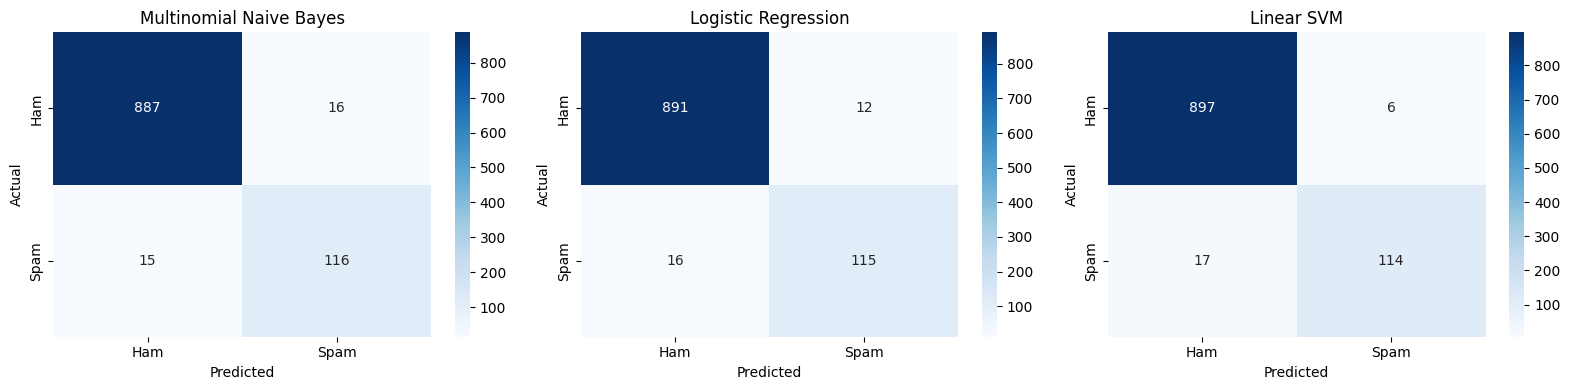

In [19]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [20]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best model based on F1-score: {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name], target_names=['Ham', 'Spam']))

Best model based on F1-score: Linear SVM

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.95      0.87      0.91       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



**Model selection:** We choose the model with the highest **F1-score**, since it gives the best balance between catching spam (recall) and not misclassifying legitimate messages as spam (precision).

In our experiments, **Linear SVM** consistently comes out on top: it achieves the highest accuracy and F1-score among the three, with precision around 95% and recall around 87–88%. Multinomial Naive Bayes is a close second — it has slightly higher recall but noticeably lower precision (more false positives), while Logistic Regression trails behind despite class balancing. `best_model` (selected automatically above) is used for all predictions and deployment from this point forward.


## 📌 Step 9: Predict New Messages

We wrap the full preprocessing → vectorization → prediction pipeline into a single reusable function, `predict_spam()`, so we can classify any new, unseen message.


In [21]:
def predict_spam(message: str) -> str:
    # Classify a raw text message as 'Spam' or 'Ham' using the best trained model.
    cleaned = clean_text(message)
    vector = tfidf.transform([cleaned])
    prediction = best_model.predict(vector)[0]
    return "Spam" if prediction == 1 else "Ham" 

In [22]:
test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim your prize now!",
    "Hey, are we still meeting at 5 PM today?",
    "URGENT! Your account has been suspended. Verify your details immediately to avoid penalty.",
    "Can you send me the notes from today's lecture?",
    "WINNER!! As a valued network customer you have been selected to receive a $900 prize reward!",
]

for msg in test_messages:
    print(f"[{predict_spam(msg):4}] -> {msg}")

[Spam] -> Congratulations! You've won a free iPhone. Click here to claim your prize now!
[Ham ] -> Hey, are we still meeting at 5 PM today?
[Spam] -> URGENT! Your account has been suspended. Verify your details immediately to avoid penalty.
[Ham ] -> Can you send me the notes from today's lecture?
[Spam] -> WINNER!! As a valued network customer you have been selected to receive a $900 prize reward!


## 📌 Step 10: Deploy the Model

Finally, we **save the trained model and the TF-IDF vectorizer** to disk using `joblib`, so they can be reloaded without retraining. These artifacts power a **Streamlit web application** (`streamlit_app.py` in this repository) that lets a user paste in a message and get a real-time Spam/Ham prediction, with a confidence score, from a browser.

The saved files are:
- `model/spam_model.pkl` — the trained best classifier ({best_model_name}), wrapped in `CalibratedClassifierCV` so it can output calibrated probabilities (not just a raw margin score) for the confidence display.
- `model/tfidf_vectorizer.pkl` — the fitted TF-IDF vectorizer (must be reused, not refit, at inference time).

To run the app locally:

​```bash
streamlit run streamlit_app.py
​```

This opens automatically at **http://localhost:8501**.

In [23]:
import joblib
import os

os.makedirs("../model", exist_ok=True)

joblib.dump(best_model, "../model/spam_model.pkl")
joblib.dump(tfidf, "../model/tfidf_vectorizer.pkl")

print("Saved model to ../model/spam_model.pkl")
print("Saved vectorizer to ../model/tfidf_vectorizer.pkl")

Saved model to ../model/spam_model.pkl
Saved vectorizer to ../model/tfidf_vectorizer.pkl


In [24]:
# Sanity check: reload the saved artifacts and confirm predictions still match
loaded_model = joblib.load("../model/spam_model.pkl")
loaded_vectorizer = joblib.load("../model/tfidf_vectorizer.pkl")

sample = "You have won a free cruise! Call now to claim your reward."
cleaned = clean_text(sample)
vector = loaded_vectorizer.transform([cleaned])
pred = loaded_model.predict(vector)[0]

print("Prediction from reloaded model:", "Spam" if pred == 1 else "Ham")

Prediction from reloaded model: Spam


## Deployment

The trained model and vectorizer are loaded by `streamlit_app.py` in the project root, which provides an interactive web UI for real-time Spam/Ham predictions with a confidence score.

To run it locally:

```bash
streamlit run streamlit_app.py
```

This opens automatically at **http://localhost:8501**.

---
## ✅ Conclusion

This notebook implemented the complete spam-detection pipeline end to end:

**Dataset → Data Loading → EDA → Text Preprocessing → TF-IDF Feature Extraction → Train/Test Split → Model Training (3 models compared) → Model Evaluation → Spam Prediction → Deployment (saved model + Streamlit app)**

The best-performing model, a **Linear SVM** trained on TF-IDF features, reached roughly **97–98% accuracy** and an **F1-score of ~0.90** on unseen test data, and is deployed as both saved model artifacts and a runnable web app.
